In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загружаем таблицу с продажами и таблицу с себестоимостью товаров
sales = pd.read_csv(r'C:\Users\22\Desktop\Костя\Данные_чистые\sales.csv', sep=';')
cost = pd.read_excel(r'C:\Users\22\Desktop\Костя\Данные_исходники\себестоимость.xlsx')

# Переименовываем колонки из таблицы о себестоимости для удобства
cost.columns = ['sku', 'cost_price']

# Присоединяем себестоимость к продажам по артикулу 
# how='left' - сотавляем все строки из sales, даже если себестоимости нет
sales = sales.merge(cost, on='sku', how='left')

## Производим первичный осмотр данных

- .info() — показывает названия колонок, типы данных и количество заполненных значений 

- .head(3) — показывает первые 3 строки таблицы 

- .describe() — считает min, max, среднее, медиану по числовым колонкам

- .isna().sum() — считает количество пустых ячеек в каждой колонке 

In [3]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2656 entries, 0 to 2655
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brand           2656 non-null   object 
 1   category        2656 non-null   object 
 2   title           2656 non-null   object 
 3   sku             2656 non-null   object 
 4   sku_WB          2656 non-null   int64  
 5   ssize           2656 non-null   object 
 6   warehouse       2656 non-null   object 
 7   orders_qty      2656 non-null   int64  
 8   sum_minus_comm  2656 non-null   float64
 9   bought_qty      2656 non-null   int64  
 10  payout          2656 non-null   float64
 11  stock           2656 non-null   int64  
 12  buyout_anomaly  2656 non-null   int64  
 13  cost_price      2367 non-null   float64
dtypes: float64(3), int64(5), object(6)
memory usage: 290.6+ KB


In [4]:
sales.head(3)

,brand,category,title,sku,sku_WB,ssize,warehouse,orders_qty,sum_minus_comm,bought_qty,payout,stock,buyout_anomaly,cost_price
0,Barbud,Видеорегистраторы автомобильные,Видеорегистратор для автомобиля зеркало,B0315темно-серый,24676507,без размера,Воронеж,2,5140.74,2,5063.48,0,0,1450.0
1,Barbud,Видеорегистраторы автомобильные,Видеорегистратор для автомобиля зеркало,B0315темно-серый,24676507,без размера,Электросталь,543,1423653.30,491,1265162.34,0,0,1450.0
2,Barbud,Видеорегистраторы автомобильные,Видеорегистратор для автомобиля зеркало,B0315темно-серый,24676507,без размера,Краснодар,540,1484457.97,465,1251105.23,231,0,1450.0


In [5]:
sales.describe()

,sku_WB,orders_qty,sum_minus_comm,bought_qty,payout,stock,buyout_anomaly,cost_price
count,2.656000e+03,2656.000000,2.656000e+03,2656.000000,2.656000e+03,2656.000000,2656.000000,2367.000000
mean,3.171554e+08,62.324548,8.302729e+04,26.182605,3.424927e+04,4.855422,0.008283,482.361639
std,1.296992e+08,155.849031,2.129712e+05,70.203735,1.026944e+05,18.823779,0.090651,94.605330
min,2.467651e+07,0.000000,0.000000e+00,-1.000000,-1.059260e+03,0.000000,0.000000,400.000000
25%,2.350972e+08,2.000000,2.398445e+03,1.000000,1.023290e+03,0.000000,0.000000,450.000000
50%,2.707716e+08,8.000000,9.764375e+03,3.000000,3.787170e+03,0.000000,0.000000,500.000000
75%,4.169326e+08,39.000000,5.056069e+04,14.000000,1.779067e+04,0.000000,0.000000,500.000000
max,8.461649e+08,1865.000000,2.446671e+06,820.000000,2.065944e+06,231.000000,1.000000,1450.000000


In [6]:
sales.isna().sum()

brand               0
category            0
title               0
sku                 0
sku_WB              0
ssize               0
warehouse           0
orders_qty          0
sum_minus_comm      0
bought_qty          0
payout              0
stock               0
buyout_anomaly      0
cost_price        289
dtype: int64

In [7]:
print('\n*** ПОКРЫТИЕ СЕБЕСТОИМОСТЬЮ ***')
with_cost = sales['cost_price'].notna().sum()
without_cost = sales['cost_price'].isna().sum()
print(f'Строк с себестоимостью: {with_cost} ({with_cost/len(sales)*100:.1f}%)')
print(f'Строк без себестоимости: {without_cost} ({without_cost/len(sales)*100:.1f}%)')


*** ПОКРЫТИЕ СЕБЕСТОИМОСТЬЮ ***
Строк с себестоимостью: 2367 (89.1%)
Строк без себестоимости: 289 (10.9%)


In [8]:
# ============================================================
# ЮНИТ-ЭКОНОМИКА
# ============================================================

# Оставляем только строки где есть себестоимость и исключаем аномальные строки 
# (догоны из прошлых периодов) которые пометили флагом buyout_anomaly на этапе очистки

df = sales[
    (sales['cost_price'].notna()) &
    (sales['buyout_anomaly'] == 0)
].copy()

print(f'Строки для анализа: {len(df)}')
print(f'Уникальных артикулов: {df['sku'].nunique()}')

# ============================================================
# Группируем по артикулу и считаем итоги
# ============================================================

unit = (
    df.groupby('sku')
    .agg(
        заказанно = ('orders_qty', 'sum'),
        выкупленно = ('bought_qty', 'sum'),
        выручка = ('sum_minus_comm', 'sum'),
        payout_total = ('payout', 'sum'),
        cost_price = ('cost_price', 'first'),
        category = ('category', 'first'),
    )
    .reset_index()
)
# Убираем артикулы с нулевыми продажами - анализировать нечего
unit = unit[unit['заказанно'] > 0].copy()

print(f'\nАртикулов после фильтрации нулевых: {len(unit)}')
print()

# ============================================================
# Считаем ключевые метрики
# ============================================================

# Прцоент выкупа - сколько % заказов реально выкупили
unit['bayout_rate'] = (unit['выкупленно'] / unit['заказанно'] * 100).round(1)

# Прибыль с единицы = payout за единицу - себестоимоть 
# Это и есть операционная прибыль с одного проданного товара
unit['net_profit_per_unit'] = (unit['payout_total'] / unit['выкупленно'] - unit['cost_price']).round(2)

# Общая прибыль по артикулу = прибыль с единицы * количество выкупленных
# Это показывает сколько рублей реально заработал каждый артикул за год
unit['total_profit'] = (unit['net_profit_per_unit'] * unit['выкупленно']).round(2)

# Маржинальность = прибыль с единицы / payout с единицы * 100
# Показывает какой % от выплаты WB остаётся продавцу после вычета себестоимости
# а не от полной цены товара, так как комиссия WB уже вычтена маркетплейсом
unit['margin_pct'] = (
    unit['net_profit_per_unit'] / (unit['payout_total'] / unit['выкупленно']) * 100
).round(1)

# Сортируем по общей прибыли — самые прибыльные сверху
unit = unit.sort_values('total_profit', ascending=False).reset_index(drop=True)

print('=== ЮНИТ-ЭКОНОМИКА ПО АРТИКУЛАМ ===')
print(unit[['sku', 'cost_price', 'net_profit_per_unit', 
            'margin_pct', 'bayout_rate', 'total_profit']].to_string())

Строки для анализа: 2360
Уникальных артикулов: 22

Артикулов после фильтрации нулевых: 16

=== ЮНИТ-ЭКОНОМИКА ПО АРТИКУЛАМ ===
                       sku  cost_price  net_profit_per_unit  margin_pct  bayout_rate  total_profit
0          T0102sing_white       450.0               666.55        59.7         45.6    9878271.00
1          T05blouse_white       500.0               800.38        61.5         37.0    7927763.90
2          T05blouse_black       500.0               879.28        63.7         44.3    7330557.36
3          T0102sing_black       450.0               657.51        59.4         53.2    7271403.09
4      T05blouse_pug_white       500.0               998.65        66.6         32.5    6230577.35
5          T05blouse_bordo       500.0              1049.06        67.7         35.5    4556067.58
6         B0315темно-серый      1450.0              1169.10        44.6         88.5    3685003.20
7      T05blouse_pug_black       500.0               847.95        62.9         3

In [9]:
# ============================================================
# ABC-АНАЛИЗ
# ============================================================
# Идея ABC-анализа проста:
# Группа A — 20% артикулов которые дают 80% прибыли (приоритет №1)
# Группа B — следующие 30% артикулов которые дают 15% прибыли
# Группа C — оставшиеся 50% артикулов которые дают 5% прибыли

# Общая прибыль по всем артикулам
total = unit['total_profit'].sum()

print(f'Общая прибыль за год: {total:.0f} руб.')
print()

# Считаем долю каждого артикула в оьщей прибыли
# cumsum() - складываем совокупность результатов сверхуни вниз
unit['profit_share_pct'] = (unit['total_profit'] / total * 100).round(2)
unit['profit_cumsum_pct'] = unit['profit_share_pct'].cumsum().round(2)

# Присваиваем группу ABC на основе накопительного %
# A — до 80%, B — до 95%, C — остальные
def assign_abc(cumsum):
    if cumsum <= 80:
        return 'A'
    elif cumsum <= 95:
        return 'B'
    else:
        return 'C'

unit['abc'] = unit['profit_cumsum_pct'].apply(assign_abc)

print('=== ABC-АНАЛИЗ ===')
print(unit[['sku', 'total_profit', 'profit_share_pct', 
            'profit_cumsum_pct', 'abc']].to_string())

print('\n=== СВОДКА ПО ГРУППАМ ===')
# Считаем сколько артикулов и какую прибыль даёт каждая группа
summary = unit.groupby('abc').agg(
    артикулов = ('sku', 'count'),
    прибыль = ('total_profit', 'sum'),
    доля_прибыли = ('profit_share_pct', 'sum')
).round(2)
print(summary)

Общая прибыль за год: 54341984 руб.

=== ABC-АНАЛИЗ ===
                       sku  total_profit  profit_share_pct  profit_cumsum_pct abc
0          T0102sing_white    9878271.00             18.18              18.18   A
1          T05blouse_white    7927763.90             14.59              32.77   A
2          T05blouse_black    7330557.36             13.49              46.26   A
3          T0102sing_black    7271403.09             13.38              59.64   A
4      T05blouse_pug_white    6230577.35             11.47              71.11   A
5          T05blouse_bordo    4556067.58              8.38              79.49   A
6         B0315темно-серый    3685003.20              6.78              86.27   B
7      T05blouse_pug_black    1974875.55              3.63              89.90   B
8          T05blouse_beige    1476598.00              2.72              92.62   B
9   T0102sing_karman_white    1209708.50              2.23              94.85   B
10  T0102sing_karman_black    1183604.99  

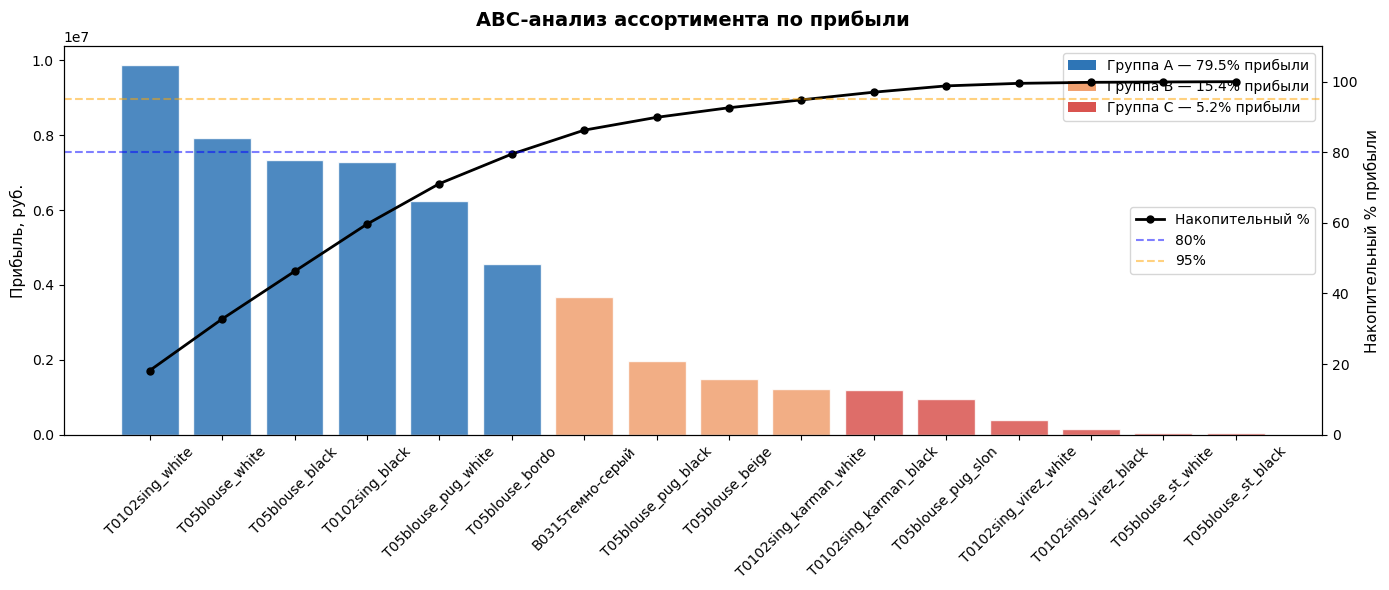

In [10]:
# Визуализация — диаграмма Парето

fig, ax1 = plt.subplots(figsize=(14, 6))

# Цвета для групп ABC
colors = ['#2E75B6' if g == 'A' else '#F0A070' if g == 'B' else '#D9534F' 
          for g in unit['abc']]

# Столбчатый график — прибыль по каждому артикулу
bars = ax1.bar(unit['sku'], unit['total_profit'], color=colors, alpha=0.85, edgecolor='white')
ax1.set_ylabel('Прибыль, руб.', fontsize=11)
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)

# Второй график поверх — накопительный % (линия Парето)
ax2 = ax1.twinx()
ax2.plot(unit['sku'], unit['profit_cumsum_pct'], 
         color='black', marker='o', linewidth=2, markersize=5, label='Накопительный %')
ax2.axhline(y=80, color='blue', linestyle='--', alpha=0.5, label='80%')
ax2.axhline(y=95, color='orange', linestyle='--', alpha=0.5, label='95%')
ax2.set_ylabel('Накопительный % прибыли', fontsize=11)
ax2.set_ylim(0, 110)

# Легенда групп
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E75B6', label='Группа A — 79.5% прибыли'),
    Patch(facecolor='#F0A070', label='Группа B — 15.4% прибыли'),
    Patch(facecolor='#D9534F', label='Группа C — 5.2% прибыли'),
]
ax1.legend(handles=legend_elements, loc='upper right')
ax2.legend(loc='center right')

plt.title('ABC-анализ ассортимента по прибыли', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Выводы ABC-анализа

- 6 артикулов группы A генерируют 79.5% всей прибыли (43.2 млн руб. из 54.3 млн)
- Лидер по прибыли — T0102sing_white: 9.9 млн руб. за год, маржа 59.7%
- Группа C (6 артикулов) приносит лишь 5.2% прибыли при 37.5% ассортимента
- T05blouse_st_black — самый слабый артикул: маржа 28.2%, прибыль 50к за год
- Видеорегистратор B0315 в группе B: высокие продажи но самая низкая маржа (44.6%) из-за высокой себестоимости 1450 руб.

In [11]:
unit

,sku,заказанно,выкупленно,выручка,payout_total,cost_price,category,bayout_rate,net_profit_per_unit,total_profit,margin_pct,profit_share_pct,profit_cumsum_pct,abc
0,T0102sing_white,32470,14820,37533544.26,16547317.58,450.0,Блузки,45.6,666.55,9878271.00,59.7,18.18,18.18,A
1,T05blouse_white,26798,9905,35728932.69,12880301.14,500.0,Блузки,37.0,800.38,7927763.90,61.5,14.59,32.77,A
2,T05blouse_black,18832,8337,26714922.28,11499055.89,500.0,Блузки,44.3,879.28,7330557.36,63.7,13.49,46.26,A
3,T0102sing_black,20780,11059,23567274.51,12247936.76,450.0,Блузки,53.2,657.51,7271403.09,59.4,13.38,59.64,A
4,T05blouse_pug_white,19176,6239,29540610.27,9350104.23,500.0,Блузки,32.5,998.65,6230577.35,66.6,11.47,71.11,A
5,T05blouse_bordo,12220,4343,19501007.70,6727576.23,500.0,Блузки,35.5,1049.06,4556067.58,67.7,8.38,79.49,A
6,B0315темно-серый,3563,3152,9510596.92,8255390.30,1450.0,Видеорегистраторы автомобильные,88.5,1169.10,3685003.20,44.6,6.78,86.27,B
7,T05blouse_pug_black,5835,2329,8122700.73,3139385.85,500.0,Блузки,39.9,847.95,1974875.55,62.9,3.63,89.90,B
8,T05blouse_beige,4758,1810,6494539.64,2381590.74,500.0,Блузки,38.0,815.80,1476598.00,62.0,2.72,92.62,B
9,T0102sing_karman_white,5857,2002,6630207.36,2110614.26,450.0,Блузки,34.2,604.25,1209708.50,57.3,2.23,94.85,B


## Выводы и рекомендации

### Юнит-экономика
Все 16 артикулов прибыльны — убыточных позиций нет.
Диапазон маржинальности: от 28.2% (T05blouse_st_black) до 67.7% (T05blouse_bordo). \
Главный фактор низкой маржи — высокая себестоимость (видеорегистратор 1450 руб.) 
и низкий процент выкупа (T0102sing_virez_white — 26.9%).

### ABC-анализ
6 артикулов группы A формируют 79.5% прибыли бизнеса. \
Концентрация здоровая — бизнес не зависит от 1-2 позиций, 
прибыль распределена между шестью артикулами.

### Рекомендации

**Группа A — защищать и масштабировать:**
Обеспечить постоянное наличие на складе, не допускать out-of-stock. \
Приоритет по рекламному бюджету — именно эти 6 артикулов.

**Группа B — растить:**
Видеорегистратор B0315 — пересмотреть ценообразование если это конкуртетно возможно или \
предпринять попытки договориться о снижении закупочной цены для улучшения маржи с 44.6%.

**Группа C — пересмотреть:**
T05blouse_st_black — маржа 28.2%, прибыль 50к за год. 
Либо поднять цену, либо вывести из ассортимента.
T0102sing_virez_white — выкуп 26.9%, нижний порог.
Проблема в карточке или размерной сетке — требует доработки.

### Ограничения анализа
- Себестоимость получена по 16 из 34 артикулов (47% ассортимента)
- Рекламные расходы не включены в расчёт прибыли
- Налоги не учитываются — считается операционная прибыль

In [12]:
# Выгружаем итоговую таблицу для Power BI
unit.to_csv(r'C:\Users\22\Desktop\Костя\Данные_чистые\unit_economics.csv', 
            index=False, sep=';', encoding='utf-8-sig')